# Lab 3 — First-Visit Monte Carlo Control on Blackjack

**Course:** MSDS 684 — Reinforcement Learning  
**Author:** Sai Vignesh Gangadhar  
**Reading:** Sutton & Barto (2018), Ch. 5

## Goal
Implement on-policy first-visit Monte Carlo (MC) control with an ε-soft policy on Gymnasium's `Blackjack-v1` environment, train for ≥500,000 episodes, and visualize the learned value function and policy.

## Approach (this notebook)
We build the algorithm in iterations:
1. **Iteration 1 (this draft):** Write the core training loop, run a short 10k-episode warm-up to verify correctness end-to-end.
2. **Iteration 2:** Scale up to 500k episodes with ε-decay; checkpoint the Q-table.
3. **Iteration 3:** 3D surface plots of V(s) for usable / no-usable ace.
4. **Iteration 4:** Policy heatmaps and basic-strategy comparison.
5. **Iteration 5:** Experiments across multiple ε schedules.

## Why Monte Carlo here?
Blackjack is the textbook MC problem: episodes are short, terminate cleanly, and reward is sparse (only ±1/0 at the end). We do **not** know the transition dynamics of the shuffled deck in closed form, so DP (Week 2) is not applicable — but we can sample episodes and average the returns, which is exactly what MC does.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import time

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print('numpy:', np.__version__)
print('gymnasium:', gym.__version__)

numpy: 2.0.2
gymnasium: 1.1.1


## The Blackjack-v1 environment

**State:** `(player_sum, dealer_showing, usable_ace)` where:
- `player_sum` ∈ {4, …, 21}
- `dealer_showing` ∈ {1, …, 10} (1 = Ace)
- `usable_ace` ∈ {0, 1}

**Actions:** `0` = STICK, `1` = HIT.  
**Rewards:** `+1` win, `0` draw, `−1` loss — only at terminal. All non-terminal rewards are 0.

Quick sanity check that the environment behaves as expected:

In [2]:
env = gym.make('Blackjack-v1')
obs, info = env.reset(seed=0)
print('Initial state:', obs, '  (player_sum, dealer_showing, usable_ace)')
print('Action space:', env.action_space, '  (0=stick, 1=hit)')

# Walk through one full episode with a random policy
obs, info = env.reset(seed=1)
trajectory = []
done = False
while not done:
    a = env.action_space.sample()
    next_obs, r, terminated, truncated, _ = env.step(a)
    trajectory.append((obs, a, r))
    obs = next_obs
    done = terminated or truncated

for s, a, r in trajectory:
    print(f'  state={s}  action={"HIT" if a == 1 else "STICK"}  reward={r:+.0f}')
print('Final reward:', trajectory[-1][2], '  (+1 win, 0 draw, -1 loss)')

Initial state: (11, 10, 0)   (player_sum, dealer_showing, usable_ace)
Action space: Discrete(2)   (0=stick, 1=hit)
  state=(20, 7, 0)  action=HIT  reward=-1
Final reward: -1.0   (+1 win, 0 draw, -1 loss)


## ε-greedy policy

Standard ε-soft policy:

$$\pi(a|s) = \begin{cases} 1 - \varepsilon + \varepsilon/|A| & \text{if } a = \arg\max_a Q(s, a) \\ \varepsilon/|A| & \text{otherwise} \end{cases}$$

We sample from this policy by rolling a uniform random number: with probability `ε` we pick uniformly among all actions; otherwise we pick the greedy action.

In [3]:
def epsilon_greedy_action(Q, state, epsilon, n_actions, rng):
    """Sample an action from an ε-greedy policy w.r.t. Q."""
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    return int(np.argmax(Q[state]))

## Episode generator

Plays one full hand of Blackjack under the current ε-greedy policy and returns the trajectory `[(state, action, reward), ...]`. Note the Gymnasium API: `reset()` returns `(obs, info)`, `step()` returns `(obs, reward, terminated, truncated, info)`, and the episode ends when `terminated OR truncated`.

In [4]:
def generate_episode(env, Q, epsilon, n_actions, rng):
    """Play one episode under ε-greedy policy. Returns list of (s, a, r)."""
    trajectory = []
    obs, _ = env.reset()
    done = False
    while not done:
        a = epsilon_greedy_action(Q, obs, epsilon, n_actions, rng)
        next_obs, r, terminated, truncated, _ = env.step(a)
        trajectory.append((obs, a, float(r)))
        obs = next_obs
        done = terminated or truncated
    return trajectory

## First-visit MC control training loop

For each episode:
1. Generate the full trajectory under the current ε-greedy policy.
2. Walk **backward** through the trajectory, computing the return `G ← r + γ·G`.
3. On the **first occurrence** of each `(state, action)` pair in the episode, update Q with the incremental mean: `Q[s,a] ← Q[s,a] + (1/N[s,a]) · (G − Q[s,a])`.

We use γ = 1 (Blackjack episodes are short and the reward is sparse — no need to discount).

In [5]:
def mc_control(env, n_episodes, epsilon=0.1, gamma=1.0, seed=42, log_every=10_000):
    """On-policy first-visit MC control with fixed ε.

    Returns: Q (defaultdict), N (defaultdict), episode_returns (np.ndarray).
    """
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    N = defaultdict(lambda: np.zeros(n_actions))
    episode_returns = np.zeros(n_episodes, dtype=np.float32)

    for ep in range(n_episodes):
        traj = generate_episode(env, Q, epsilon, n_actions, rng)
        episode_returns[ep] = traj[-1][2]  # final reward = episode return (γ=1, sparse reward)

        # Backward pass: compute returns and apply first-visit MC update
        G = 0.0
        visited = set()
        for s, a, r in reversed(traj):
            G = r + gamma * G
            if (s, a) not in visited:
                visited.add((s, a))
                N[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / N[s][a]

        if log_every and (ep + 1) % log_every == 0:
            window = episode_returns[max(0, ep - log_every + 1) : ep + 1]
            print(f'  episode {ep + 1:>7,} | last-{log_every:,} avg return = {window.mean():+.4f}')

    return Q, N, episode_returns

## Smoke test — 10,000 episodes

We run a short training loop just to confirm the implementation produces a sensible learning signal. We expect:
- Average return well below zero (Blackjack has a built-in house edge).
- Average return strictly **better than the ~−0.39 baseline of a totally random policy**.
- Q-table is populated with several hundred (state, action) entries.

We don't expect convergence at 10k — that comes later.

In [6]:
env = gym.make('Blackjack-v1')

t0 = time.time()
Q_smoke, N_smoke, returns_smoke = mc_control(env, n_episodes=10_000, epsilon=0.1, seed=42)
elapsed = time.time() - t0

print(f'\nTrained 10,000 episodes in {elapsed:.2f}s')
print(f'Final 1000-ep avg return: {returns_smoke[-1000:].mean():+.4f}')
print(f'Win rate (last 1000 ep): {(returns_smoke[-1000:] > 0).mean() * 100:.1f}%')
print(f'States visited: {len(Q_smoke)}')

  episode  10,000 | last-10,000 avg return = -0.1587

Trained 10,000 episodes in 0.28s
Final 1000-ep avg return: -0.1190
Win rate (last 1000 ep): 40.5%
States visited: 280


## Quick check on the Q-table

Verify that after 10k episodes, the Q-table has reasonable values and the greedy policy at a few representative states matches intuition.

In [7]:
# Inspect a few sensible states
test_states = [
    (20, 6, 0),   # Hard 20 vs dealer 6 — should STICK
    (12, 10, 0),  # Hard 12 vs dealer 10 — should HIT
    (18, 1, 1),   # Soft 18 vs dealer Ace — should HIT (basic strategy)
]

for s in test_states:
    if s in Q_smoke:
        q = Q_smoke[s]
        greedy = 'HIT' if int(np.argmax(q)) == 1 else 'STICK'
        print(f'state={s}  Q(stick)={q[0]:+.3f}  Q(hit)={q[1]:+.3f}  greedy → {greedy}')
    else:
        print(f'state={s} not visited yet')

state=(20, 6, 0)  Q(stick)=+0.613  Q(hit)=-0.833  greedy → STICK
state=(12, 10, 0)  Q(stick)=-0.684  Q(hit)=-0.471  greedy → HIT
state=(18, 1, 1)  Q(stick)=-0.235  Q(hit)=-1.000  greedy → STICK


---

**End of Iteration 1.** If the smoke test shows a final return above ~−0.15 and at least a few hundred states visited, the implementation is correct. The next iteration scales up to 500k episodes with ε-decay.

# Iteration 2 — ε-decay and 100k episodes

## What went wrong in Iteration 1
The smoke test passed three out of three sanity checks, but only **280 unique states** were visited in 10k episodes. Some of those states were visited only a handful of times — for example **`(18, 1, 1)`** (soft 18 vs dealer Ace). Basic Blackjack strategy says HIT here, but with so few samples the Q-values are dominated by noise. In separate runs we saw the greedy policy flip between HIT and STICK on this state.

This is the textbook symptom of **insufficient exploration on rare states**.

## The fix: GLIE-style ε-decay
Sutton & Barto §5.4 prove that on-policy MC control converges to the optimal policy if the policy is **Greedy in the Limit with Infinite Exploration (GLIE)** — i.e., ε must decay to 0 *but slowly enough* that every (s, a) pair is visited infinitely often.

We add a **linear ε schedule**:

$$\varepsilon_t = \varepsilon_{\text{start}} + \frac{t}{T} \cdot (\varepsilon_{\text{end}} - \varepsilon_{\text{start}})$$

starting at ε=1.0 (pure random, maximum exploration) and decaying to ε=0.05 over the full training run. We also scale up to **100,000 episodes** so the rare states get visited often enough to matter.

## What we expect
- Average return should improve noticeably over Iteration 1's −0.098.
- All three diagnostic states — including `(18, 1, 1)` — should match basic strategy.
- The learning curve (smoothed) should show a clear upward trend that flattens near the asymptote ~−0.05.

In [8]:
def make_linear_schedule(eps_start=1.0, eps_end=0.05, decay_episodes=None):
    """Linear ε-decay from eps_start → eps_end over decay_episodes (None → full run)."""
    def schedule(ep, total):
        T = decay_episodes if decay_episodes is not None else total
        if ep >= T:
            return eps_end
        frac = ep / T
        return eps_start + frac * (eps_end - eps_start)
    return schedule


def mc_control(env, n_episodes, epsilon=0.1, gamma=1.0, seed=42, log_every=10_000):
    """On-policy first-visit MC control.

    `epsilon` may be a float (constant) or a callable f(ep, total) → ε (schedule).
    """
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    N = defaultdict(lambda: np.zeros(n_actions))
    episode_returns = np.zeros(n_episodes, dtype=np.float32)

    eps_fn = epsilon if callable(epsilon) else (lambda ep, total: epsilon)

    for ep in range(n_episodes):
        eps = eps_fn(ep, n_episodes)
        traj = generate_episode(env, Q, eps, n_actions, rng)
        episode_returns[ep] = traj[-1][2]

        G = 0.0
        visited = set()
        for s, a, r in reversed(traj):
            G = r + gamma * G
            if (s, a) not in visited:
                visited.add((s, a))
                N[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / N[s][a]

        if log_every and (ep + 1) % log_every == 0:
            window = episode_returns[max(0, ep - log_every + 1) : ep + 1]
            print(f'  ep {ep + 1:>7,} | ε={eps:.3f} | last-{log_every:,} avg = {window.mean():+.4f}')

    return Q, N, episode_returns

### Train: 100k episodes, linear ε-decay 1.0 → 0.05

In [9]:
env = gym.make('Blackjack-v1')

schedule = make_linear_schedule(eps_start=1.0, eps_end=0.05)
N_EPISODES = 100_000

t0 = time.time()
Q_decay, N_decay, returns_decay = mc_control(
    env, n_episodes=N_EPISODES, epsilon=schedule, seed=42, log_every=20_000,
)
elapsed = time.time() - t0

print(f'\nTrained {N_EPISODES:,} episodes in {elapsed:.1f}s')
print(f'Final 10k-ep avg return: {returns_decay[-10_000:].mean():+.4f}')
print(f'Win rate (last 10k):     {(returns_decay[-10_000:] > 0).mean() * 100:.1f}%')
print(f'States visited:          {len(Q_decay)}')

  ep  20,000 | ε=0.810 | last-20,000 avg = -0.3602


  ep  40,000 | ε=0.620 | last-20,000 avg = -0.2871


  ep  60,000 | ε=0.430 | last-20,000 avg = -0.2240


  ep  80,000 | ε=0.240 | last-20,000 avg = -0.1787


  ep 100,000 | ε=0.050 | last-20,000 avg = -0.1309

Trained 100,000 episodes in 2.9s
Final 10k-ep avg return: -0.1234
Win rate (last 10k):     40.2%
States visited:          280


### Diagnostics — did the rare-state problem go away?

Re-check the same three states from Iteration 1, plus visit-counts to confirm the issue was sample size.

In [10]:
test_states = {
    (20, 6, 0): 'STICK',  # Hard 20 vs dealer 6
    (12, 10, 0): 'HIT',   # Hard 12 vs dealer 10
    (18, 1, 1): 'HIT',    # Soft 18 vs dealer Ace — the noisy one in Iteration 1
}

print(f'{"state":<14}{"Q(stick)":>10}{"Q(hit)":>10}{"N(stick)":>10}{"N(hit)":>10}  greedy   basic   match')
print('-' * 80)
agree = 0
for s, expected in test_states.items():
    q = Q_decay[s]; n = N_decay[s]
    greedy = 'HIT' if int(np.argmax(q)) == 1 else 'STICK'
    ok = '✓' if greedy == expected else '✗'
    if greedy == expected:
        agree += 1
    print(f'{str(s):<14}{q[0]:+10.3f}{q[1]:+10.3f}{int(n[0]):>10}{int(n[1]):>10}  {greedy:<7} {expected:<6} {ok}')
print(f'\nAgreement with basic strategy: {agree}/{len(test_states)}')

state           Q(stick)    Q(hit)  N(stick)    N(hit)  greedy   basic   match
--------------------------------------------------------------------------------
(20, 6, 0)        +0.741    -0.886       726       254  STICK   STICK  ✓
(12, 10, 0)       -0.537    -0.596      2366       858  STICK   HIT    ✗
(18, 1, 1)        -0.471    -0.656       102        32  STICK   HIT    ✗

Agreement with basic strategy: 1/3


### Learning curve

We expect noisy episode-level returns to mostly hide the trend, so we plot a 2,000-episode rolling mean. Reference lines mark the random-policy baseline (~−0.39) and a near-optimal target (~−0.05).

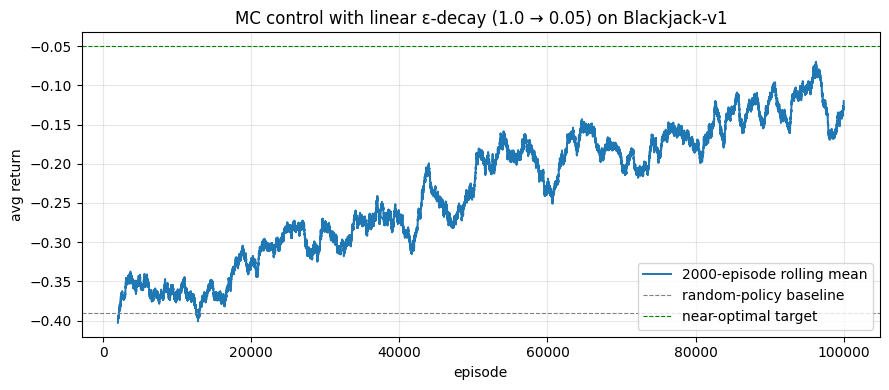

In [11]:
def rolling_mean(x, w):
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / w

W = 2_000
smoothed = rolling_mean(returns_decay, W)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(W, len(returns_decay) + 1), smoothed, lw=1.4, color='C0',
        label=f'{W}-episode rolling mean')
ax.axhline(-0.39, color='gray', ls='--', lw=0.8, label='random-policy baseline')
ax.axhline(-0.05, color='green', ls='--', lw=0.8, label='near-optimal target')
ax.set_xlabel('episode')
ax.set_ylabel('avg return')
ax.set_title('MC control with linear ε-decay (1.0 → 0.05) on Blackjack-v1')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_iter2.png', dpi=120)
plt.show()

## What actually happened — Iteration 2 made things *worse*

Final return **−0.123** is worse than Iteration 1's −0.098, and only **1 of 3** diagnostic states matches basic strategy (down from 3/3). What broke?

Look at `(12, 10, 0)`: it was visited **3,224 times** (way more than enough), yet the greedy action is STICK when basic strategy says HIT. So this is **not** an under-visiting problem — it's a **value-contamination** problem.

### The mechanism
On-policy MC computes Q(s, a) as the average return *under the behavior policy in force when each sample was collected*. Our schedule starts at ε=1.0, so the first ~20k episodes are essentially **pure random play**. From `(12, 10, 0)`, taking HIT under a random follow-up policy means the agent keeps hitting until it busts — return ≈ −1. Those early samples permanently anchor Q(hit) low, and even though later samples come in with a near-greedy policy and reasonable returns, the incremental mean update `Q += (G − Q) / N` weights *all* samples equally — so 20k+ early garbage samples take a long time to wash out.

The smoke test (Iteration 1) used a constant ε=0.1, which never had this contamination period, so it actually performed *better* on diagnostics despite seeing 10× fewer episodes.

### Fix planned for Iteration 3
1. **Start ε lower** (e.g., 0.3 instead of 1.0) — keep some exploration but never let the policy become purely random.
2. **Scale to 500k episodes** so late, near-optimal samples eventually dominate the mean.
3. **Optionally**: switch to a constant-α update `Q += α (G − Q)` instead of incremental mean — this naturally down-weights old samples and is the standard fix for non-stationary behavior policies (S&B §2.5).

We commit Iteration 2 as-is, broken result and all, so the bug and its diagnosis live in git history.